# Knee-point detection

A knee point is the cycle where capacity fade transitions from a long, slow plateau into rapid
acceleration — the "cliff" that precedes end of life. `batlab.features.detect_knee()` implements
the L-method (Satopaa et al., "Finding a 'Kneedle' in a Haystack: Detecting Knee Points in System
Behavior", ICDCSW 2011, adapted for SOH curves).

In [1]:
import matplotlib.pyplot as plt
from batlab.datasets import load_severson_cells, load_oxford_cells
from batlab.features import detect_knee, degradation_phases

## Severson (dense per-cycle data) — the case this method is built for

In [2]:
sev = load_severson_cells()
print(f"{len(sev)} Severson cells loaded")

# Pick the cell with the most cycles for the clearest knee.
cell_id = max(sev, key=lambda c: len(sev[c]))
df = sev[cell_id]
result = detect_knee(df["soh_pct"], df["cycle_number"])
print(f"{cell_id}: {result}")

46 Severson cells loaded
S-b1c4: {'detected': np.True_, 'cycle': 932, 'soh_at_knee': 97.3, 'confidence': 0.326, 'phase': 'Accelerating'}


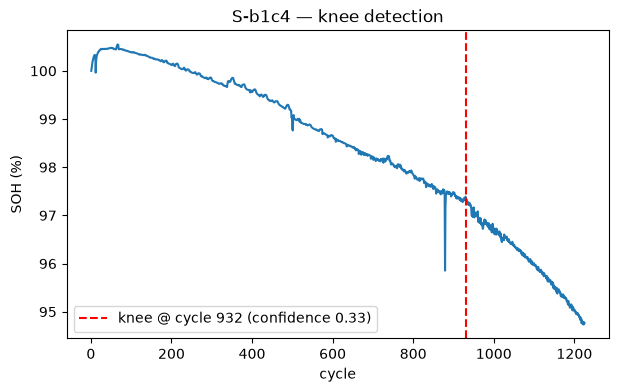

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["cycle_number"], df["soh_pct"], lw=1.5)
if result["detected"]:
    ax.axvline(result["cycle"], color="red", ls="--",
               label=f"knee @ cycle {result['cycle']} (confidence {result['confidence']:.2f})")
    ax.legend()
ax.set_xlabel("cycle"); ax.set_ylabel("SOH (%)")
ax.set_title(f"{cell_id} — knee detection")
plt.show()

In [4]:
phases = degradation_phases(df["soh_pct"], df["cycle_number"])
phases.value_counts()

Plateau         881
Accelerating    294
Early            50
Name: count, dtype: int64

## Oxford (sparse checkpoint data) — where this method honestly does NOT apply

Oxford's cells have only ~8-14 Reference Performance Test checkpoints across their whole life,
not dense per-cycle data. `detect_knee()`'s `min_cycles` guard means it correctly refuses to
call a knee on this few points rather than overfitting noise into a false "cliff" — the same
honesty pattern `batlab.datasets.oxford` already applies by not running this data through the
GBRT+LCO pipeline at all.

In [5]:
ox = load_oxford_cells()
ox_id = next(iter(ox))
ox_df = ox[ox_id]
print(f"{ox_id}: only {len(ox_df)} checkpoints (not cycles)")

ox_result = detect_knee(ox_df["soh_pct"], ox_df["checkpoint_index"], min_cycles=50)
print(ox_result)
assert ox_result["detected"] is False, "correctly refuses to detect a knee on this little data"
print("\ndetect_knee() correctly declines to call a knee here -- 8-14 points is too few to trust.")

OX-9: only 14 checkpoints (not cycles)
{'detected': False, 'cycle': None, 'soh_at_knee': None, 'confidence': 0.0, 'phase': 'Early'}

detect_knee() correctly declines to call a knee here -- 8-14 points is too few to trust.


## Cite this

In [6]:
import batlab
print(batlab.cite())
print()
print(batlab.cite(dataset="severson2019"))

@software{batlab,
  title  = {batlab: a citable, honest research library for battery degradation analysis},
  author = {Hosseini, Ali},
  year   = {2026},
  url    = {https://github.com/seyedali1996lb-svg/battery-intelligence-platform},
  doi    = {10.5281/zenodo.21346275},
  note   = {Standardized dataset loaders, leave-cell-out-validated SOH/RUL models, reproducible benchmark manifests, and a model-agnostic validation harness that can grade a third party's forecaster in a sandbox.}
}

@article{severson2019data,
  title   = {Data-driven prediction of battery cycle life before capacity degradation},
  author  = {Severson, Kristen A. and Attia, Peter M. and Jin, Norman and Perkins, Nicholas and Jiang, Benben and Yang, Zi and Chen, Michael H. and Aykol, Muratahan and Herring, Patrick K. and Fraggedakis, Dimitrios and Bazant, Martin Z. and Harris, Stephen J. and Chueh, William C. and Braatz, Richard D.},
  journal = {Nature Energy},
  volume  = {4},
  pages   = {383--391},
  year    = {20